## Connect to drive



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import required Libraries

In [3]:
import pandas as pd
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Analysis Using Status Clean column/Uganda Cleaned Data set for analysis.csv')

In [6]:
df.head()

,row_id,source,lat_deg,lon_deg,report_date,status_id,water_source_clean,water_tech_category,clean_country_name,clean_adm1,...,install_year,Water_Point_Age,management_clean,pay_clean,status_clean,subjective_quality_clean,photo_lnk,data_lnk,facility_type,count
0,4,"Ministry of Water and Environment, Uganda",3.017319,30.936143,4/29/2010,Yes,Borehole/Tubewell,Hand Pump,Uganda,Northern,...,1998,28,Community Management,Fees collected,"Functional, needs repair",unknown,Not available,https://catalog.waterpointdata.org/datasets/mw...,Improved,1
1,5,"Ministry of Water and Environment, Uganda",3.033349,30.955287,4/29/2010,Yes,Borehole/Tubewell,Hand Pump,Uganda,Northern,...,1996,30,Community Management,Fees collected,"Functional, needs repair",unknown,Not available,https://catalog.waterpointdata.org/datasets/mw...,Improved,1
2,17,"Ministry of Water and Environment, Uganda",3.022349,30.933175,4/29/2010,Yes,Protected Well,unknown,Uganda,Northern,...,1997,29,Community Management,Unknown,"Functional, needs repair",unknown,Not available,https://catalog.waterpointdata.org/datasets/mw...,Improved,1
3,18,"Ministry of Water and Environment, Uganda",3.017763,30.936709,4/29/2010,No,Borehole/Tubewell,Hand Pump,Uganda,Northern,...,1998,28,Other,Unknown,Non-Functional,unknown,Not available,https://catalog.waterpointdata.org/datasets/mw...,Improved,1
4,35,"Ministry of Water and Environment, Uganda",3.017768,30.934865,4/29/2010,No,Rainwater Harvesting,unknown,Uganda,Northern,...,2002,24,Community Management,Unknown,Non-Functional,unknown,Not available,https://catalog.waterpointdata.org/datasets/mw...,Improved,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130843 entries, 0 to 130842
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   row_id                    130843 non-null  int64  
 1   source                    130843 non-null  object 
 2   lat_deg                   130843 non-null  float64
 3   lon_deg                   130843 non-null  float64
 4   report_date               130843 non-null  object 
 5   status_id                 130843 non-null  object 
 6   water_source_clean        130843 non-null  object 
 7   water_tech_category       130843 non-null  object 
 8   clean_country_name        130843 non-null  object 
 9   clean_adm1                130843 non-null  object 
 10  clean_adm2                130843 non-null  object 
 11  clean_adm3                130843 non-null  object 
 12  clean_adm4                130843 non-null  object 
 13  install_year              130843 non-null  i

In [9]:
df.shape

(130843, 23)

In [10]:
df.isnull().sum()

,0
row_id,0
source,0
lat_deg,0
lon_deg,0
report_date,0
status_id,0
water_source_clean,0
water_tech_category,0
clean_country_name,0
clean_adm1,0


In [11]:
# columns clean_adm3 and clean_adm4 will be dropped because the analysis will be done with the district level population which is column clean_adm2 level
df = df.drop(columns=['clean_adm3'])
df = df.drop(columns=['clean_adm4'])

In [12]:
# data_lnk column is dropped because for performing analysis it is not necessary
df = df.drop(columns=['data_lnk'])

In [13]:
# column photo_lnk will also be dropped
df = df.drop(columns=['photo_lnk'])

In [14]:
df.head()

,row_id,source,lat_deg,lon_deg,report_date,status_id,water_source_clean,water_tech_category,clean_country_name,clean_adm1,clean_adm2,install_year,Water_Point_Age,management_clean,pay_clean,status_clean,subjective_quality_clean,facility_type,count
0,4,"Ministry of Water and Environment, Uganda",3.017319,30.936143,4/29/2010,Yes,Borehole/Tubewell,Hand Pump,Uganda,Northern,Arua,1998,28,Community Management,Fees collected,"Functional, needs repair",unknown,Improved,1
1,5,"Ministry of Water and Environment, Uganda",3.033349,30.955287,4/29/2010,Yes,Borehole/Tubewell,Hand Pump,Uganda,Northern,Arua,1996,30,Community Management,Fees collected,"Functional, needs repair",unknown,Improved,1
2,17,"Ministry of Water and Environment, Uganda",3.022349,30.933175,4/29/2010,Yes,Protected Well,unknown,Uganda,Northern,Arua,1997,29,Community Management,Unknown,"Functional, needs repair",unknown,Improved,1
3,18,"Ministry of Water and Environment, Uganda",3.017763,30.936709,4/29/2010,No,Borehole/Tubewell,Hand Pump,Uganda,Northern,Arua,1998,28,Other,Unknown,Non-Functional,unknown,Improved,1
4,35,"Ministry of Water and Environment, Uganda",3.017768,30.934865,4/29/2010,No,Rainwater Harvesting,unknown,Uganda,Northern,Arua,2002,24,Community Management,Unknown,Non-Functional,unknown,Improved,1


In [15]:
# As we are working on country Uganda, column country_name will be dropped
df = df.drop(columns=['clean_country_name'])

In [16]:
# column named source is also not required now, the values (about source) in this column will be mentioned in the repot
df = df.drop(columns=['source'])

In [17]:
df['report_date'] = pd.to_datetime(df['report_date'])

In [18]:
df['report_year'] = df['report_date'].dt.year
df['report_year'] = df['report_date'].dt.month

In [19]:
df = df.drop(columns=['report_date'])

In [20]:
status_mapping = {
"Functional":2,
"Functional, needs repair":1,
"Functional, not in use":1,
"Non-Functional":0,
"Non-Functional, dry season":0,
"Abandoned/Decommissioned":0
}

df["status_numeric"] = df["status_clean"].map(status_mapping)

df = df.dropna(subset=["status_numeric"])

df["status_numeric"] = df["status_numeric"].astype(int)

In [21]:
df.shape

(130842, 18)

In [24]:
df["status_numeric"].value_counts()

,count
status_numeric,
1,83372
0,39650
2,7820


In [25]:
df.isnull().sum().sort_values(ascending=False)

,0
row_id,0
lat_deg,0
lon_deg,0
status_id,0
water_source_clean,0
water_tech_category,0
clean_adm1,0
clean_adm2,0
install_year,0
Water_Point_Age,0


## Checking minimum and maximum age

In [26]:
df["Water_Point_Age"].min(), df["Water_Point_Age"].max()

(1, 122)

In [27]:
df["Water_Point_Age"].describe()

,Water_Point_Age
count,130842.000000
mean,23.106655
std,9.537007
min,1.000000
25%,18.000000
50%,22.000000
75%,26.000000
max,122.000000


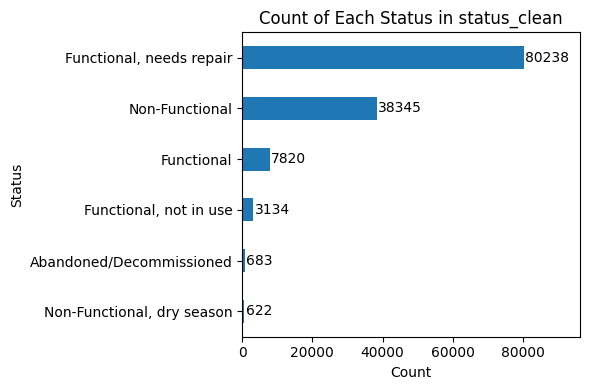

In [28]:
import matplotlib.pyplot as plt

# Count values (sorted decreasing)
status_counts = df['status_clean'].value_counts()

plt.figure(figsize=(6,4))

bars = plt.barh(status_counts.index, status_counts.values, height=0.45)

# Largest on top
plt.gca().invert_yaxis()

plt.xlabel('Count')
plt.ylabel('Status')
plt.title('Count of Each Status in status_clean')

max_val = status_counts.max()

for bar in bars:
    width = bar.get_width()
    plt.text(width + max_val*0.005,             # small space after bar
             bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center',
             ha='left',
             fontsize=10)

# Extend axis slightly so text stays inside
plt.xlim(0, max_val * 1.2)

plt.tight_layout()
plt.show()

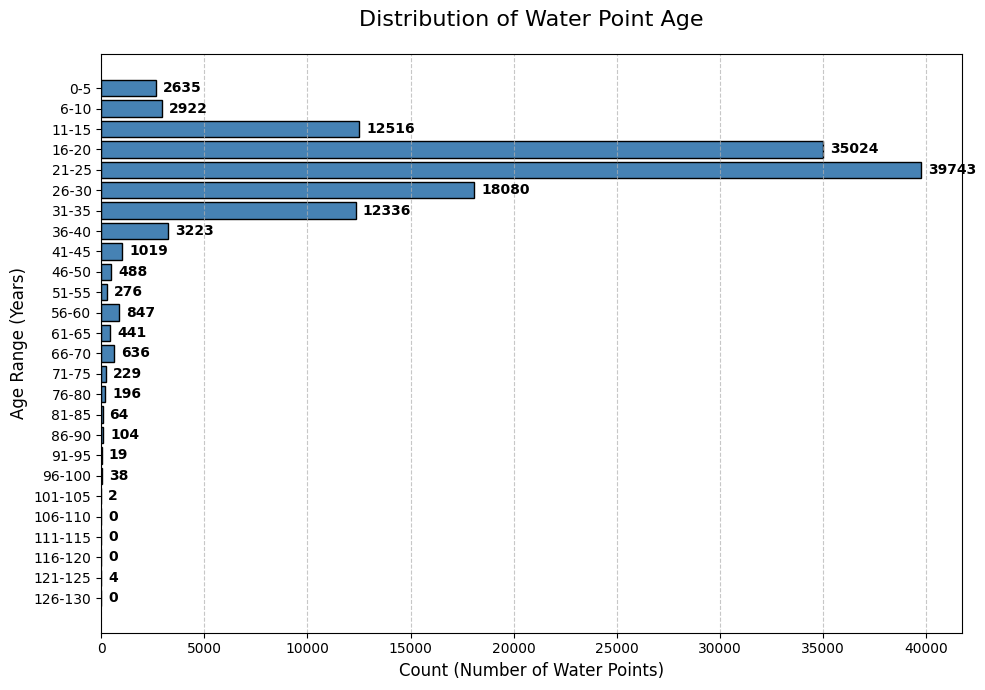

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define bin edges and labels (0-5, 6-10, 11-15, etc.)
max_age = int(df["Water_Point_Age"].max())
edges = [-1] + list(range(5, max_age + 10, 5))
labels = [f"{edges[i]+1}-{edges[i+1]}" for i in range(len(edges)-1)]

# 2. Categorize the data into these groups
df['Age_Group'] = pd.cut(df["Water_Point_Age"], bins=edges, labels=labels)

# 3. Create the summary table
table_df = df['Age_Group'].value_counts().sort_index().reset_index()
table_df.columns = ["Age Range (Years)", "Count"]

# 4. Create the Matplotlib Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(table_df["Age Range (Years)"], table_df["Count"], color='steelblue', edgecolor='black')

# Add counts at the end of each bar
ax.bar_label(bars, padding=5, fontweight='bold')

# Formatting
ax.set_title("Distribution of Water Point Age", fontsize=16, pad=20)
ax.set_xlabel("Count (Number of Water Points)", fontsize=12)
ax.set_ylabel("Age Range (Years)", fontsize=12)
ax.invert_yaxis()  # Keep youngest age groups at the top
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

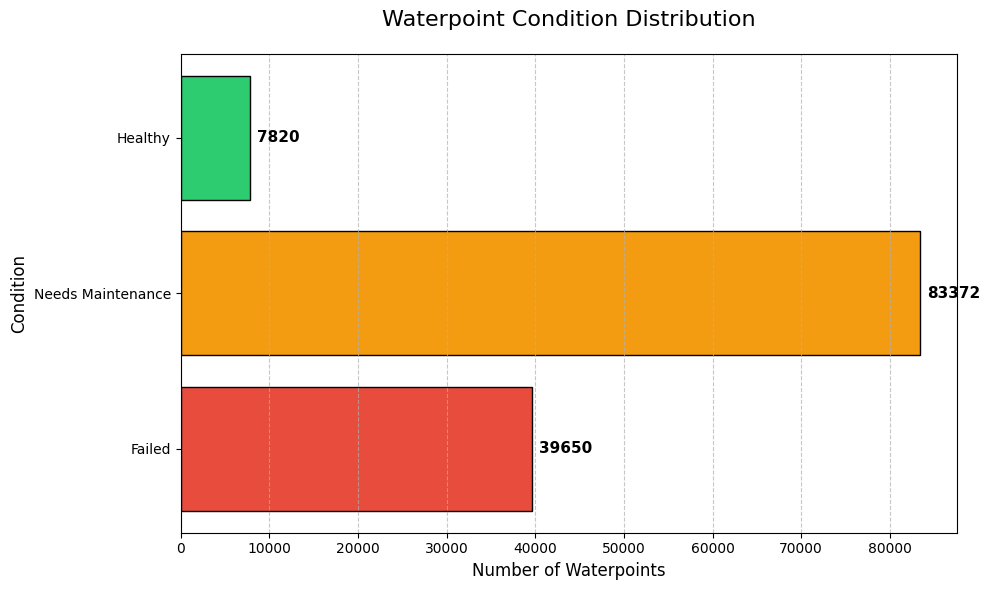

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Map the numeric status to descriptive labels
status_map = {
    0: "Failed",
    1: "Needs Maintenance",
    2: "Healthy"
}

# 2. Prepare the summary table
# We reindex to ensure a logical order: Healthy -> Needs Maintenance -> Failed
table_df = df['status_numeric'].map(status_map).value_counts().reindex(["Healthy", "Needs Maintenance", "Failed"]).reset_index()
table_df.columns = ["Condition", "Count"]

# 3. Create the Matplotlib Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Custom colors for intuitive status representation
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = ax.barh(table_df["Condition"], table_df["Count"], color=colors, edgecolor='black')

# Add counts at the end of each bar
ax.bar_label(bars, padding=5, fontweight='bold', fontsize=11)

# Formatting
ax.set_title("Waterpoint Condition Distribution", fontsize=16, pad=20)
ax.set_xlabel("Number of Waterpoints", fontsize=12)
ax.set_ylabel("Condition", fontsize=12)
ax.invert_yaxis()  # Logical flow: Top status at the top
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [31]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())
    print("Number of categories:", df[col].nunique())
    print("--------------")

status_id
['Yes' 'No' 'Unknown']
Number of categories: 3
--------------
water_source_clean
['Borehole/Tubewell' 'Protected Well' 'Rainwater Harvesting' 'Piped Water'
 'Undefined Well' 'unknown' 'Surface Water (River/Stream/Lake/Pond/Dam)'
 'Delivered Water' 'Protected Spring' 'Sand or Sub-surface Dam'
 'Undefined Spring' 'Unprotected Well' 'Packaged Water']
Number of categories: 13
--------------
water_tech_category
['Hand Pump' 'unknown' 'Public Tapstand' 'Motorized Pump'
 'Rope and Bucket']
Number of categories: 5
--------------
clean_adm1
['Northern' 'Western' 'Eastern' 'Central']
Number of categories: 4
--------------
clean_adm2
['Arua' 'Kamwenge' 'Luuka' 'Kitagwenda' 'Jinja' 'Mayuge' 'Lamwo' 'Otuke'
 'Ibanda' 'Masindi' 'Nebbi' 'Madi Okollo' 'Yumbe' 'Zombo' 'Kiryandongo'
 'Maracha' 'Iganga' 'Nakaseke' 'Lira' 'Kumi' 'Kaliro' 'Kamuli' 'Koboko'
 'Nwoya' 'Kyegegwa' 'Obongi' 'Moyo' 'Adjumani' 'Pakwach' 'Amuru' 'Wakiso'
 'Agago' 'Pader' 'Kitgum' 'Dokolo' 'Alebtong' 'Kalaki' 'Amuria' 'Amo

In [32]:
df['water_source_clean'] = df['water_source_clean'].replace({
'Borehole/Tubewell':'Borehole',
'Protected Well':'Well',
'Unprotected Well':'Well',
'Undefined Well':'Well',
'Protected Spring':'Spring',
'Undefined Spring':'Spring',
'Delivered Water':'Piped',
'Piped Water':'Piped',
'Dam':'Sand or Sub-surface Dam'
})

In [33]:
df['water_tech_category'] = df['water_tech_category'].replace('unknown','Unknown')

In [34]:
df['management_clean'] = df['management_clean'].replace({
'Community Management':'Community',
'School Management':'Institutional',
'Health Care Facility':'Institutional',
'Religious Institution':'Institutional',
'Direct Government Operation':'Government',
'Private Operator/Delegated Management':'Private',
'Other Institutional Management':'Institutional',
'No Management':'None',
'Unknown':'Other',
'unknown':'Other',
'other':'Other'
})

In [35]:
df['pay_clean'] = df['pay_clean'].replace({
'Fees collected':'Paid',
'Fees collected – metered':'Paid',
'Fees collected – monthly':'Paid',
'Fees collected – seasonally':'Paid',
'Fees collected – annually':'Paid',
'No payment':'Free',
'Unknown':'Unknown',
'unknown':'Unknown'
})

In [36]:
df['subjective_quality_clean'] = df['subjective_quality_clean'].replace({
'Acceptable quality':'Good',
'Bad smell':'Poor',
'Bad color':'Poor',
'Bad taste':'Poor',
'Unacceptable quality':'Poor',
'unknown':'Unknown'
})

In [37]:
df['water_source_clean'].value_counts()

,count
water_source_clean,
Well,52701
Borehole,40235
Rainwater Harvesting,15890
Piped,9637
unknown,9260
Spring,1407
Surface Water (River/Stream/Lake/Pond/Dam),946
Sand or Sub-surface Dam,765
Packaged Water,1


In [38]:
df['water_tech_category'].value_counts()

,count
water_tech_category,
Unknown,74135
Hand Pump,38229
Public Tapstand,17297
Motorized Pump,1041
Rope and Bucket,140


In [39]:
df['management_clean'].value_counts()

,count
management_clean,
Community,88322
Other,19783
Private,11346
Institutional,11204
Government,184
None,3


In [40]:
df['pay_clean'].value_counts()

,count
pay_clean,
Unknown,84509
Paid,41446
Free,4887


In [41]:
df['subjective_quality_clean'].value_counts()

,count
subjective_quality_clean,
Unknown,126568
Good,2932
Poor,1342


In [42]:
df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,management_clean,pay_clean,status_clean,subjective_quality_clean,facility_type,count,report_year,status_numeric,Age_Group
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,Community,Paid,"Functional, needs repair",Unknown,Improved,1,4,1,26-30
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,Community,Paid,"Functional, needs repair",Unknown,Improved,1,4,1,26-30
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,Community,Unknown,"Functional, needs repair",Unknown,Improved,1,4,1,26-30
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,Other,Unknown,Non-Functional,Unknown,Improved,1,4,0,26-30
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,Community,Unknown,Non-Functional,Unknown,Improved,1,4,0,21-25


In [43]:
df['status_clean'].value_counts()

,count
status_clean,
"Functional, needs repair",80238
Non-Functional,38345
Functional,7820
"Functional, not in use",3134
Abandoned/Decommissioned,683
"Non-Functional, dry season",622


In [44]:
df['status_clean'] = df['status_clean'].replace({
'Functional, needs repair':'Needs Maintenance',
'Functional, not in use':'Needs Maintenance',
'Non-Functional, dry season':'Failed',
'Non-Functional':'Failed',
'Abandoned/Decommissioned':'Failed',
'Functional':'Healthy'
})

In [45]:
df['status_clean'].value_counts()

,count
status_clean,
Needs Maintenance,83372
Failed,39650
Healthy,7820


In [46]:
source_status = pd.crosstab(df['water_source_clean'], df['status_clean'])

source_status

status_clean,Failed,Healthy,Needs Maintenance
water_source_clean,,,
Borehole,14767,2222,23246
Packaged Water,1,0,0
Piped,2850,553,6234
Rainwater Harvesting,3831,47,12012
Sand or Sub-surface Dam,267,473,25
Spring,608,684,115
Surface Water (River/Stream/Lake/Pond/Dam),516,171,259
Well,14536,3457,34708
unknown,2274,213,6773


## Water Technology Vs Failure

In [47]:
tech_status = pd.crosstab(df['water_tech_category'], df['status_clean'])

tech_status

status_clean,Failed,Healthy,Needs Maintenance
water_tech_category,,,
Hand Pump,11511,2826,23892
Motorized Pump,927,105,9
Public Tapstand,4488,475,12334
Rope and Bucket,140,0,0
Unknown,22584,4414,47137


## Water point Age

In [48]:
df['Water_Point_Age'].describe()

,Water_Point_Age
count,130842.000000
mean,23.106655
std,9.537007
min,1.000000
25%,18.000000
50%,22.000000
75%,26.000000
max,122.000000


In [49]:
df['age_group'] = pd.cut(
    df['Water_Point_Age'],
    bins=[0,5,10,15,20,25,30,35,40,45,200],
    labels=['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','41-45','46+']
)

In [50]:
df['age_group'].value_counts().sort_index()

,count
age_group,
0-5,2635
6-10,2922
11-15,12516
16-20,35024
21-25,39743
26-30,18080
31-35,12336
36-40,3223
41-45,1019


In [51]:
age_status = pd.crosstab(df['age_group'], df['status_clean'])
age_status

status_clean,Failed,Healthy,Needs Maintenance
age_group,,,
0-5,2219,368,48
6-10,1666,1045,211
11-15,2871,1402,8243
16-20,7814,2070,25140
21-25,14097,2212,23434
26-30,5631,513,11936
31-35,3189,104,9043
36-40,860,31,2332
41-45,338,27,654


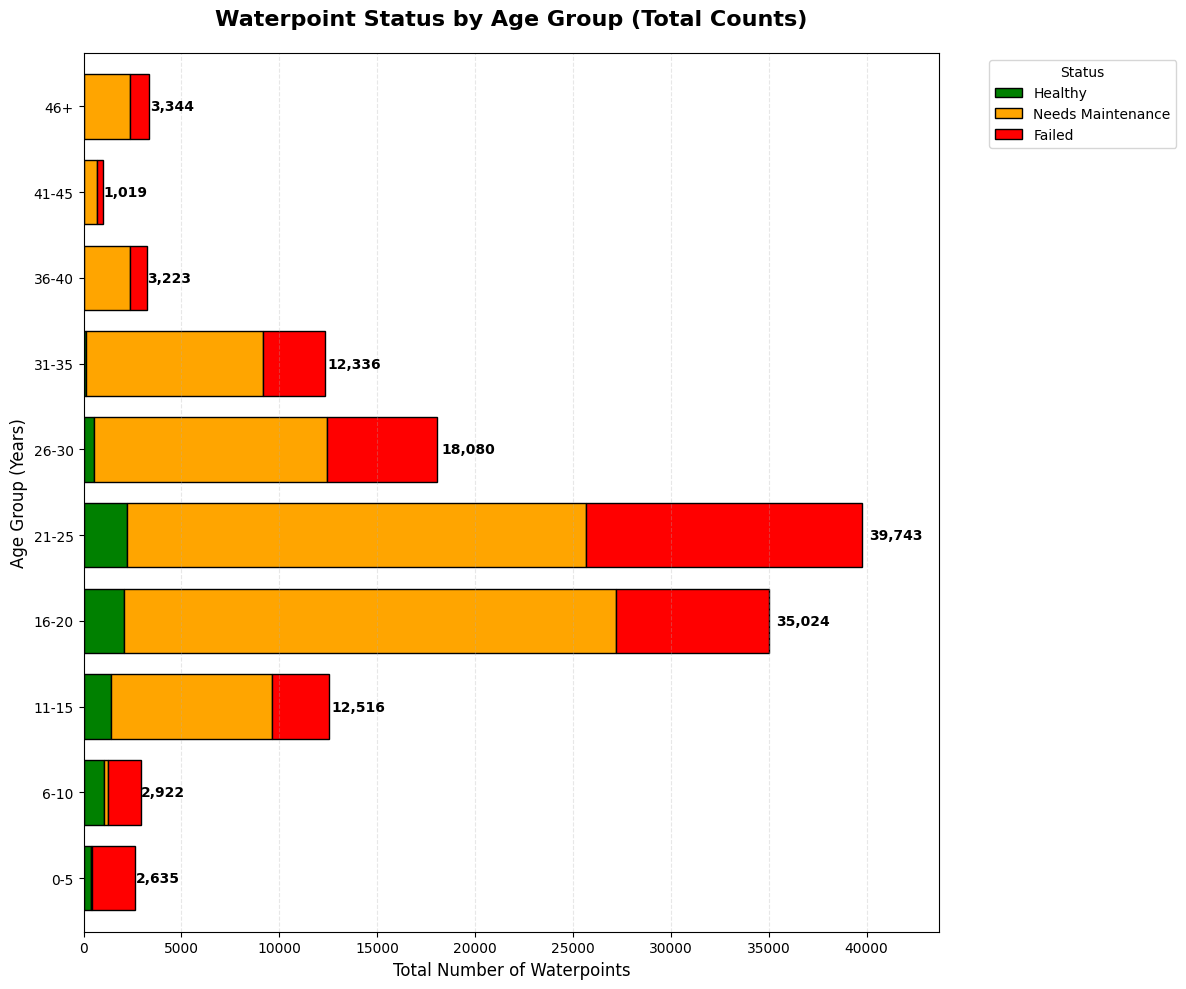

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the crosstab for counts
# (Assumes 'age_group' and 'status_clean' are already mapped/prepared in your df)
age_status_count = pd.crosstab(df['age_group'], df['status_clean'])

# Reorder for logical progression (Healthy -> Needs Maintenance -> Failed)
cols_order = ["Healthy", "Needs Maintenance", "Failed"]
age_status_count = age_status_count[[c for c in cols_order if c in age_status_count.columns]]

# 2. Calculate row totals for labeling
totals = age_status_count.sum(axis=1)

# 3. Create the Visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Standard color palette
colors = ['Green', 'Orange', 'Red']

# Plot the stacked bars (Note: No bar_labels are added inside the loop)
age_status_count.plot(
    kind='barh',
    stacked=True,
    color=colors,
    ax=ax,
    edgecolor='black',
    width=0.75
)

# 4. Add ONLY the Total count at the end of each stacked bar
for i, total in enumerate(totals):
    if total > 0:
        ax.text(
            total + (total * 0.01), # Add a small dynamic padding
            i,
            f'{int(total):,}',      # Format with thousands comma
            va='center',
            fontweight='bold',
            fontsize=10
        )

# 5. Final Formatting
plt.title("Waterpoint Status by Age Group (Total Counts)", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Total Number of Waterpoints", fontsize=12)
plt.ylabel("Age Group (Years)", fontsize=12)

# Ensure the x-axis has enough room for the labels
ax.set_xlim(0, totals.max() * 1.1)

# Position the legend outside
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add subtle vertical gridlines
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Management Vs Water Point Status

In [53]:
management_status = pd.crosstab(df['management_clean'], df['status_clean'])

management_status

status_clean,Failed,Healthy,Needs Maintenance
management_clean,,,
Community,19936,2497,65889
Government,170,8,6
Institutional,3862,208,7134
None,3,0,0
Other,13139,4971,1673
Private,2540,136,8670


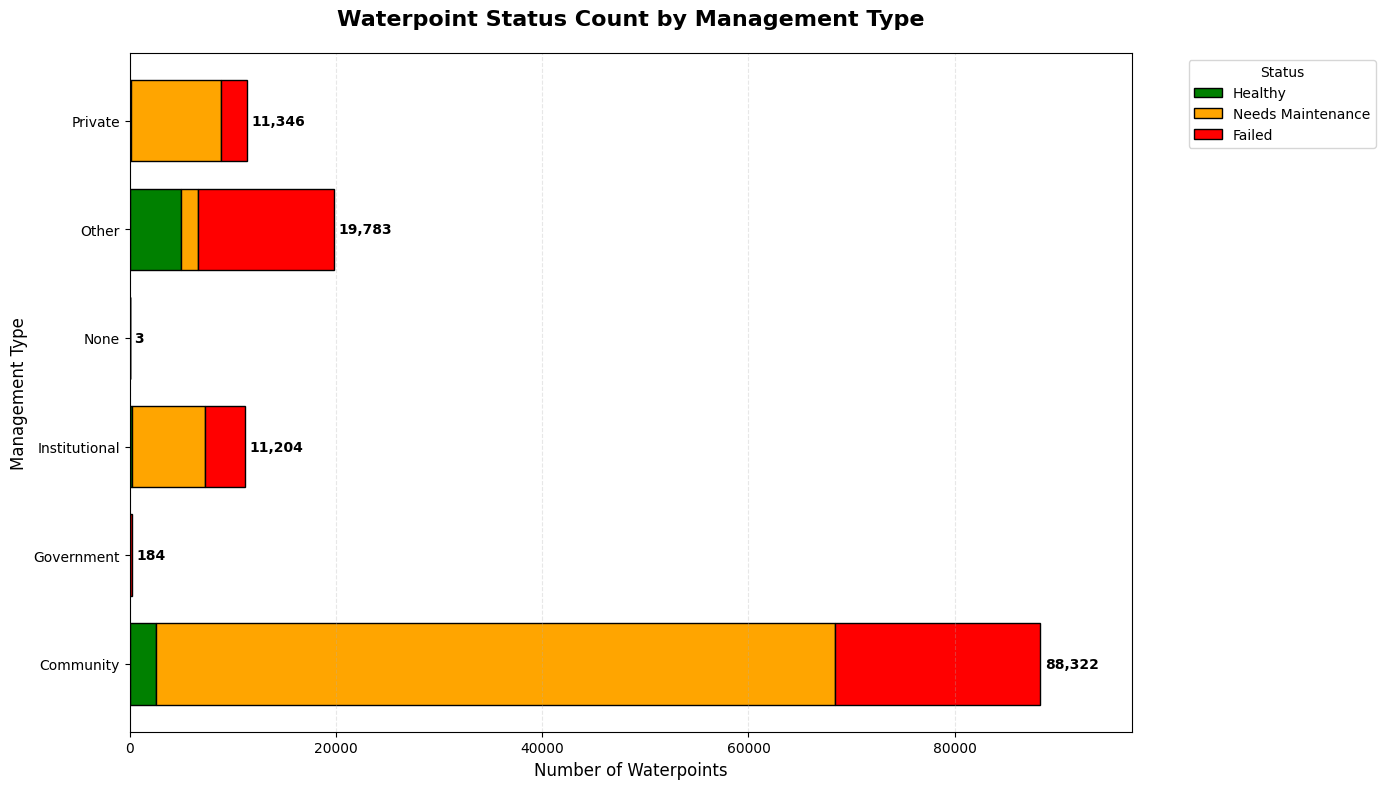

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the crosstab for counts
# (Assumes 'management_clean' and 'status_clean' are already prepared)
management_status = pd.crosstab(df['management_clean'], df['status_clean'])

# Reorder columns for logical flow (Healthy -> Needs Maintenance -> Failed)
cols_order = ["Healthy", "Needs Maintenance", "Failed"]
management_status = management_status[[c for c in cols_order if c in management_status.columns]]

# 2. Calculate row totals for clear labeling at the end
totals = management_status.sum(axis=1)

# 3. Create the Visualization (Horizontal Stacked Bar)
fig, ax = plt.subplots(figsize=(14, 8))

# Standard severity color palette
colors = ['Green', 'Orange', 'Red']

management_status.plot(
    kind='barh',
    stacked=True,
    color=colors,
    ax=ax,
    edgecolor='black',
    width=0.75
)

# 4. Add ONLY the Total count at the end of each bar to prevent overlapping
for i, total in enumerate(totals):
    if total > 0:
        ax.text(
            total + (totals.max() * 0.005), # Consistent small padding
            i,
            f'{int(total):,}',
            va='center',
            fontweight='bold',
            fontsize=10
        )

# 5. Final Formatting
plt.title("Waterpoint Status Count by Management Type", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Number of Waterpoints", fontsize=12)
plt.ylabel("Management Type", fontsize=12)

# Ensure the x-axis can fit the labels
ax.set_xlim(0, totals.max() * 1.1)

# Position the legend outside the plot
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add subtle gridlines for the count scale
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

clean_adm1 vs ststus_clean

In [55]:
region_status = pd.crosstab(df['clean_adm1'], df['status_clean'])

region_status

status_clean,Failed,Healthy,Needs Maintenance
clean_adm1,,,
Central,6931,8,17665
Eastern,10535,992,18211
Northern,10400,1038,16641
Western,11784,5782,30855


In [56]:
district_total = df.groupby('clean_adm2').size().reset_index(name='total_waterpoints')

district_total.head()

,clean_adm2,total_waterpoints
0,Abim,730
1,Adjumani,629
2,Agago,1007
3,Alebtong,922
4,Amolatar,356


In [57]:
district_status = pd.crosstab(df['clean_adm2'], df['status_clean']).reset_index()

district_status.head()

status_clean,clean_adm2,Failed,Healthy,Needs Maintenance
0,Abim,529,0,201
1,Adjumani,112,0,517
2,Agago,346,0,661
3,Alebtong,293,0,629
4,Amolatar,101,0,255


In [58]:
district_summary = pd.merge(
    district_total,
    district_status,
    on='clean_adm2',
    how='left'
)

district_summary.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance
0,Abim,730,529,0,201
1,Adjumani,629,112,0,517
2,Agago,1007,346,0,661
3,Alebtong,922,293,0,629
4,Amolatar,356,101,0,255


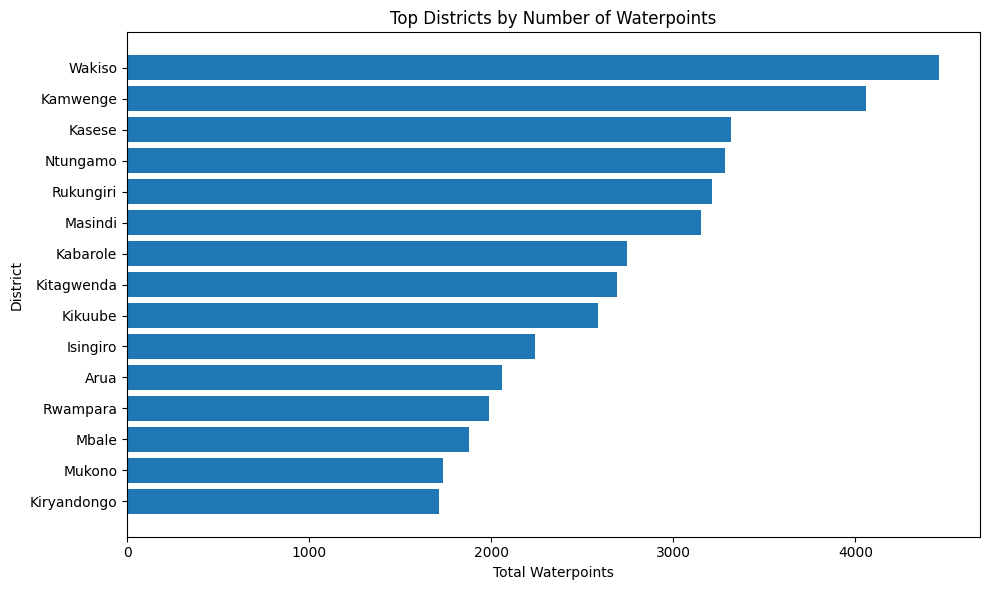

In [59]:
top_districts = district_summary.sort_values(
    by='total_waterpoints',
    ascending=False
).head(15)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(top_districts['clean_adm2'], top_districts['total_waterpoints'])

plt.title("Top Districts by Number of Waterpoints")
plt.xlabel("Total Waterpoints")
plt.ylabel("District")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [60]:
df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,management_clean,pay_clean,status_clean,subjective_quality_clean,facility_type,count,report_year,status_numeric,Age_Group,age_group
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,Community,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,Community,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,Community,Unknown,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,Other,Unknown,Failed,Unknown,Improved,1,4,0,26-30,26-30
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,Community,Unknown,Failed,Unknown,Improved,1,4,0,21-25,21-25


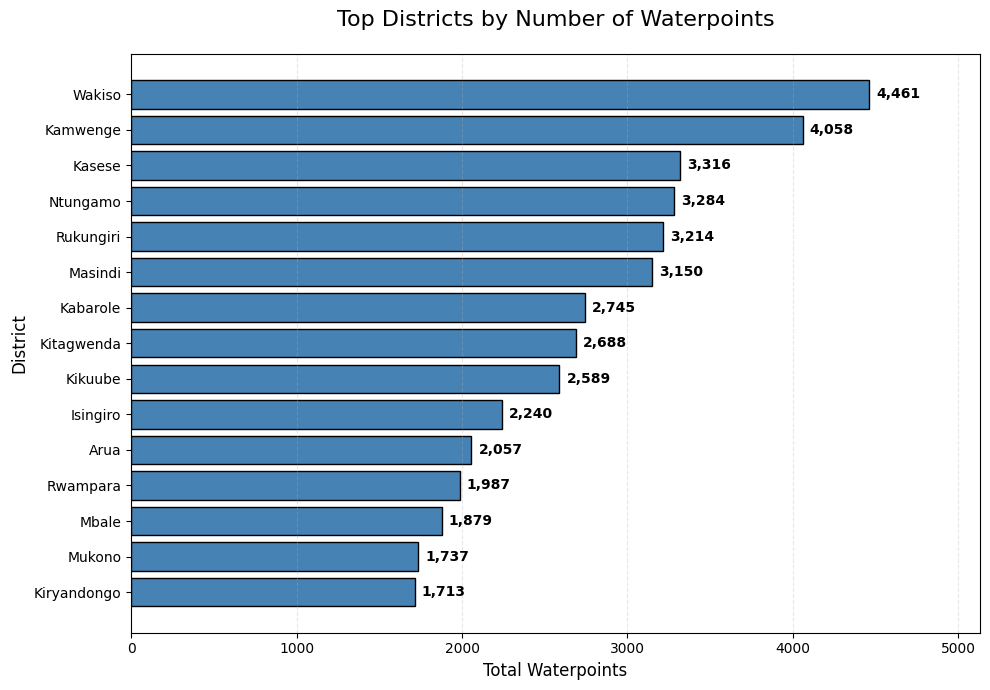

In [61]:
import matplotlib.pyplot as plt

# 1. Sort and select top 15 districts
top_districts = district_summary.sort_values(
    by='total_waterpoints',
    ascending=False
).head(15)

# 2. Create the Visualization
plt.figure(figsize=(10, 7))

# Plot horizontal bars
bars = plt.barh(top_districts['clean_adm2'], top_districts['total_waterpoints'],
                color='steelblue', edgecolor='black')

# 3. Add total counts at the end of each bar
plt.bar_label(bars, padding=5, fontweight='bold', fmt='{:,.0f}')

# 4. FIX: Set x-axis limit with a buffer to prevent labels from cutting off
# We calculate the max value and add 15% extra space
max_val = top_districts['total_waterpoints'].max()
plt.xlim(0, max_val * 1.15)

# 5. Formatting
plt.title("Top Districts by Number of Waterpoints", fontsize=16, pad=20)
plt.xlabel("Total Waterpoints", fontsize=12)
plt.ylabel("District", fontsize=12)

# Ensure the highest count is at the top
plt.gca().invert_yaxis()

# Add light gridlines
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
df.to_csv("waterpoint_dataset_without_population_dataset_integration.csv", index = False)

In [63]:
from google.colab import files
files.download("waterpoint_dataset_without_population_dataset_integration.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,management_clean,pay_clean,status_clean,subjective_quality_clean,facility_type,count,report_year,status_numeric,Age_Group,age_group
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,Community,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,Community,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,Community,Unknown,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,Other,Unknown,Failed,Unknown,Improved,1,4,0,26-30,26-30
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,Community,Unknown,Failed,Unknown,Improved,1,4,0,21-25,21-25


In [65]:
from google.colab import files
uploaded = files.upload()

Saving Population Data Set District wise.xlsx to Population Data Set District wise.xlsx


In [66]:
import pandas as pd

pop_df = pd.read_excel("Population Data Set District wise.xlsx")

In [67]:
pop_df.head()

,District,Region,Population
0,Buikwe,Central,520158
1,Bukomansimbi,Central,197568
2,Butambala,Central,146516
3,Buvuma,Central,110832
4,Gomba,Central,199120


In [68]:
pop_df.columns = pop_df.columns.str.replace('\n',' ').str.strip()

In [69]:
pop_df.columns

Index(['District', 'Region', 'Population'], dtype='object')

In [70]:
pop_df['District'].unique()

array(['Buikwe', 'Bukomansimbi', 'Butambala', 'Buvuma', 'Gomba',
       'Kalangala', 'Kalungu', 'Kampala', 'Kassanda', 'Kayunga', 'Kiboga',
       'Kyankwanzi', 'Kyotera', 'Luwero', 'Lwengo', 'Lyantonde', 'Masaka',
       'Mityana', 'Mpigi', 'Mubende', 'Mukono', 'Nakaseke', 'Nakasongola',
       'Rakai', 'Ssembabule', 'Wakiso', 'Amuria', 'Budaka', 'Bududa',
       'Bugiri', 'Bugweri', 'Bukedea', 'Bukwo', 'Bulambuli', 'Busia',
       'Butaleja', 'Butebo', 'Buyende', 'Iganga', 'Jinja', 'Kaberamaido',
       'Kalaki', 'Kaliro', 'Kamuli', 'Kapchorwa', 'Kapelebyong',
       'Katakwi', 'Kibuku', 'Kumi', 'Kween', 'Luuka', 'Manafwa', 'Mayuge',
       'Mbale', 'Namayingo', 'Namisindwa', 'Namutumba', 'Ngora',
       'Pallisa', 'Serere', 'Sironko', 'Soroti', 'Tororo', 'Abim',
       'Adjumani', 'Agago', 'Alebtong', 'Amolatar', 'Amudat', 'Amuru',
       'Apac', 'Arua', 'Dokolo', 'Gulu', 'Kaabong', 'Karenga', 'Kitgum',
       'Koboko', 'Kole', 'Kotido', 'Kwania', 'Lamwo', 'Lira',
       'Madi Okoll

In [71]:
pop_df['District'].value_counts()

,count
District,
Buikwe,1
Bukomansimbi,1
Butambala,1
Buvuma,1
Gomba,1
...,...
Rubirizi,1
Rukiga,1
Rukungiri,1


In [72]:
district_summary.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance
0,Abim,730,529,0,201
1,Adjumani,629,112,0,517
2,Agago,1007,346,0,661
3,Alebtong,922,293,0,629
4,Amolatar,356,101,0,255


In [73]:
district_merged = district_summary.merge(
    pop_df,
    left_on='clean_adm2',
    right_on='District',
    how='left'
)

In [74]:
district_merged.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population
0,Abim,730,529,0,201,Abim,Northern,144084
1,Adjumani,629,112,0,517,Adjumani,Northern,300590
2,Agago,1007,346,0,661,Agago,Northern,307235
3,Alebtong,922,293,0,629,Alebtong,Northern,283509
4,Amolatar,356,101,0,255,Amolatar,Northern,188715


In [75]:
district_merged['Population'].isnull().sum()

np.int64(0)

## Waterpoint Density
Waterpoints per 10,000 people

In [76]:
district_merged['waterpoints_per_10k'] = (
    district_merged['total_waterpoints'] /
    district_merged['Population']
) * 10000

In [77]:
district_merged.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890
1,Adjumani,629,112,0,517,Adjumani,Northern,300590,20.925513
2,Agago,1007,346,0,661,Agago,Northern,307235,32.776214
3,Alebtong,922,293,0,629,Alebtong,Northern,283509,32.521013
4,Amolatar,356,101,0,255,Amolatar,Northern,188715,18.864425


## Failure Ratio per District
## Failure Ratio = Failed Waterpointa/Total Waterpoints

In [78]:
district_merged['failure_ratio'] = (
    district_merged['Failed'] /
    district_merged['total_waterpoints']
)

In [79]:
district_merged.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890,0.724658
1,Adjumani,629,112,0,517,Adjumani,Northern,300590,20.925513,0.178060
2,Agago,1007,346,0,661,Agago,Northern,307235,32.776214,0.343595
3,Alebtong,922,293,0,629,Alebtong,Northern,283509,32.521013,0.317787
4,Amolatar,356,101,0,255,Amolatar,Northern,188715,18.864425,0.283708


In [80]:
high_risk_districts = district_merged.sort_values(
    by='failure_ratio',
    ascending=False
)

high_risk_districts.head(15)

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio
59,Kazo,36,36,0,0,Kazo,Western,208898,1.723329,1.000000
95,Moroto,743,615,0,128,Moroto,Northern,103639,71.691159,0.827725
100,Nabilatuk,436,339,0,97,Nabilatuk,Northern,136785,31.874840,0.777523
48,Kampala,16,12,0,4,Kampala,Central,1797722,0.089002,0.750000
107,Napak,979,711,0,268,Napak,Northern,211830,46.216306,0.726251
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890,0.724658
101,Nakapiripirit,557,400,1,156,Nakapiripirit,Northern,111681,49.874195,0.718133
105,Namisindwa,1330,946,0,384,Namisindwa,Eastern,257346,51.681394,0.711278
90,Mayuge,1612,1126,0,486,Mayuge,Eastern,577563,27.910375,0.698511
113,Obongi,415,268,0,147,Obongi,Northern,142983,29.024429,0.645783


In [81]:
district_merged.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890,0.724658
1,Adjumani,629,112,0,517,Adjumani,Northern,300590,20.925513,0.178060
2,Agago,1007,346,0,661,Agago,Northern,307235,32.776214,0.343595
3,Alebtong,922,293,0,629,Alebtong,Northern,283509,32.521013,0.317787
4,Amolatar,356,101,0,255,Amolatar,Northern,188715,18.864425,0.283708


## Districts with Highest Waterpoint Failures

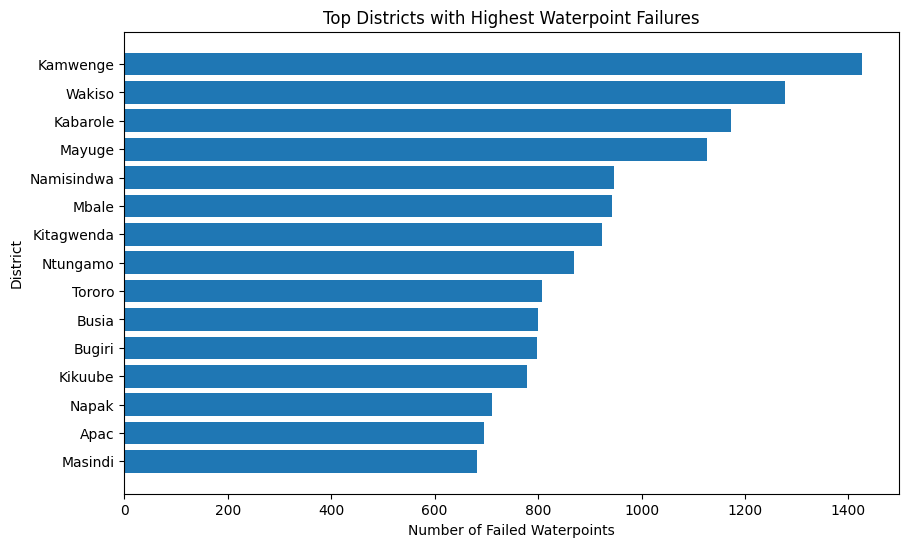

In [82]:
top_failures = district_merged.sort_values(
    by='Failed',
    ascending=False
).head(15)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_failures['clean_adm2'],
    top_failures['Failed']
)

plt.title("Top Districts with Highest Waterpoint Failures")
plt.xlabel("Number of Failed Waterpoints")
plt.ylabel("District")

plt.gca().invert_yaxis()

plt.show()

In [83]:
district_merged.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890,0.724658
1,Adjumani,629,112,0,517,Adjumani,Northern,300590,20.925513,0.178060
2,Agago,1007,346,0,661,Agago,Northern,307235,32.776214,0.343595
3,Alebtong,922,293,0,629,Alebtong,Northern,283509,32.521013,0.317787
4,Amolatar,356,101,0,255,Amolatar,Northern,188715,18.864425,0.283708


## Maintenance Cluster Detection

In [84]:
district_merged.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890,0.724658
1,Adjumani,629,112,0,517,Adjumani,Northern,300590,20.925513,0.178060
2,Agago,1007,346,0,661,Agago,Northern,307235,32.776214,0.343595
3,Alebtong,922,293,0,629,Alebtong,Northern,283509,32.521013,0.317787
4,Amolatar,356,101,0,255,Amolatar,Northern,188715,18.864425,0.283708


In [85]:
district_merged['maintenance_ratio'] = (
    district_merged['Needs Maintenance'] /
    district_merged['total_waterpoints']
)

In [86]:
district_merged.head()

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio,maintenance_ratio
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890,0.724658,0.275342
1,Adjumani,629,112,0,517,Adjumani,Northern,300590,20.925513,0.178060,0.821940
2,Agago,1007,346,0,661,Agago,Northern,307235,32.776214,0.343595,0.656405
3,Alebtong,922,293,0,629,Alebtong,Northern,283509,32.521013,0.317787,0.682213
4,Amolatar,356,101,0,255,Amolatar,Northern,188715,18.864425,0.283708,0.716292


In [87]:
district_merged.sort_values(
    by='maintenance_ratio',
    ascending=False
).head(15)

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio,maintenance_ratio
66,Kisoro,4,0,0,4,Kisoro,Western,433662,0.092238,0.000000,1.000000
18,Bukwo,322,15,0,307,Bukwo,Eastern,120000,26.833333,0.046584,0.953416
11,Bududa,742,41,0,701,Bududa,Eastern,268970,27.586720,0.055256,0.944744
92,Mbarara,1444,102,0,1342,Mbarara,Western,438464,32.933148,0.070637,0.929363
133,Yumbe,747,56,0,691,Yumbe,Northern,972351,7.682411,0.074967,0.925033
53,Kapelebyong,264,24,0,240,Kapelebyong,Eastern,185000,14.270270,0.090909,0.909091
109,Ngora,354,33,0,321,Ngora,Eastern,196000,18.061224,0.093220,0.906780
52,Kapchorwa,493,46,0,447,Kapchorwa,Eastern,196000,25.153061,0.093306,0.906694
46,Kaliro,425,35,5,385,Kaliro,Eastern,286397,14.839541,0.082353,0.905882
74,Kween,228,23,0,205,Kween,Eastern,132000,17.272727,0.100877,0.899123


In [88]:
# district_merged.to_excel("Population_Analysis_Dataset.xlsx", index=False)

In [89]:
df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,management_clean,pay_clean,status_clean,subjective_quality_clean,facility_type,count,report_year,status_numeric,Age_Group,age_group
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,Community,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,Community,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,Community,Unknown,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,Other,Unknown,Failed,Unknown,Improved,1,4,0,26-30,26-30
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,Community,Unknown,Failed,Unknown,Improved,1,4,0,21-25,21-25


Class Distribution:
status_numeric
1    83372
0    39650
2     7820
Name: count, dtype: int64

Class Distribution (%):
status_numeric
1    63.72
0    30.30
2     5.98
Name: proportion, dtype: float64


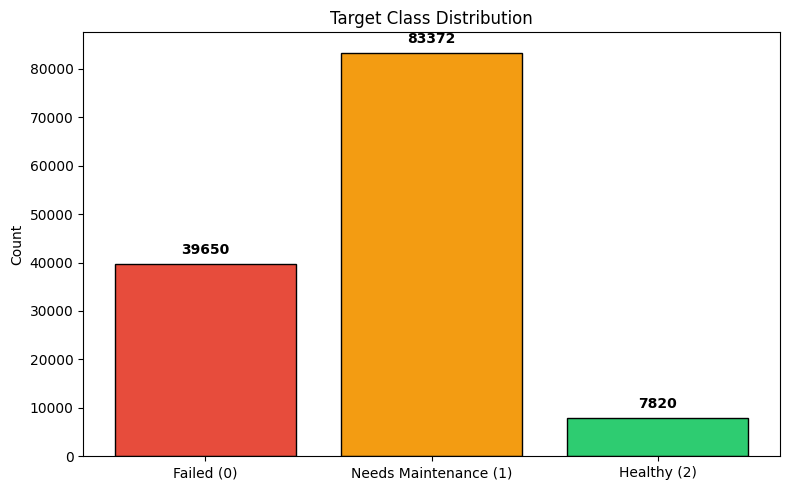

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

y = df["status_numeric"]

print("Class Distribution:")
print(y.value_counts())
print()
print("Class Distribution (%):")
print(y.value_counts(normalize=True).mul(100).round(2))

# Correct order: 0=Failed, 1=Needs Maintenance, 2=Healthy
counts = [y.value_counts()[0], y.value_counts()[1], y.value_counts()[2]]
colors = ['#e74c3c', '#f39c12', '#2ecc71']
labels = ['Failed (0)', 'Needs Maintenance (1)', 'Healthy (2)']

plt.figure(figsize=(8,5))
bars = plt.bar(labels, counts, color=colors, edgecolor='black')
plt.bar_label(bars, padding=5, fontweight='bold')
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [91]:
features = [
    "status_id",
    "water_source_clean",
    "water_tech_category",
    "management_clean",
    "age_group",
    "clean_adm1",
    "population_per_waterpoint"
]

# Check if population_per_waterpoint exists
print("Columns in df:", df.columns.tolist())
print()

# Check nulls in each feature
print("Null counts in ML features:")
print(df[["status_id","water_source_clean","water_tech_category",
          "management_clean","age_group","clean_adm1"]].isnull().sum())

Columns in df: ['row_id', 'lat_deg', 'lon_deg', 'status_id', 'water_source_clean', 'water_tech_category', 'clean_adm1', 'clean_adm2', 'install_year', 'Water_Point_Age', 'management_clean', 'pay_clean', 'status_clean', 'subjective_quality_clean', 'facility_type', 'count', 'report_year', 'status_numeric', 'Age_Group', 'age_group']

Null counts in ML features:
status_id              0
water_source_clean     0
water_tech_category    0
management_clean       0
age_group              0
clean_adm1             0
dtype: int64


In [92]:
district_merged['population_per_waterpoint'] = (
    district_merged['Population'] /
    district_merged['total_waterpoints']
)

In [93]:
district_merged.head(20)

,clean_adm2,total_waterpoints,Failed,Healthy,Needs Maintenance,District,Region,Population,waterpoints_per_10k,failure_ratio,maintenance_ratio,population_per_waterpoint
0,Abim,730,529,0,201,Abim,Northern,144084,50.664890,0.724658,0.275342,197.375342
1,Adjumani,629,112,0,517,Adjumani,Northern,300590,20.925513,0.178060,0.821940,477.885533
2,Agago,1007,346,0,661,Agago,Northern,307235,32.776214,0.343595,0.656405,305.099305
3,Alebtong,922,293,0,629,Alebtong,Northern,283509,32.521013,0.317787,0.682213,307.493492
4,Amolatar,356,101,0,255,Amolatar,Northern,188715,18.864425,0.283708,0.716292,530.098315
5,Amudat,338,200,0,138,Amudat,Northern,203358,16.620935,0.591716,0.408284,601.650888
6,Amuria,481,76,0,405,Amuria,Eastern,329000,14.620061,0.158004,0.841996,683.991684
7,Amuru,710,281,1,428,Amuru,Northern,247574,28.678294,0.395775,0.602817,348.695775
8,Apac,1485,695,204,586,Apac,Northern,221962,66.903344,0.468013,0.394613,149.469360
9,Arua,2057,379,0,1678,Arua,Northern,1080000,19.046296,0.184249,0.815751,525.036461


In [94]:
district_merged.to_excel("Population_Analysis_Dataset.xlsx", index=False)

In [95]:
pop_feature = district_merged[['clean_adm2','population_per_waterpoint']]

In [96]:
df = df.merge(
    pop_feature,
    on='clean_adm2',
    how='left'
)

In [97]:
df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,...,pay_clean,status_clean,subjective_quality_clean,facility_type,count,report_year,status_numeric,Age_Group,age_group,population_per_waterpoint
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,...,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30,525.036461
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,...,Paid,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30,525.036461
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,...,Unknown,Needs Maintenance,Unknown,Improved,1,4,1,26-30,26-30,525.036461
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,...,Unknown,Failed,Unknown,Improved,1,4,0,26-30,26-30,525.036461
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,...,Unknown,Failed,Unknown,Improved,1,4,0,21-25,21-25,525.036461


In [98]:
df[['clean_adm2','population_per_waterpoint']].head()

,clean_adm2,population_per_waterpoint
0,Arua,525.036461
1,Arua,525.036461
2,Arua,525.036461
3,Arua,525.036461
4,Arua,525.036461


In [99]:
df.to_excel("Data set for building ML Model.xlsx", index=False)

In [100]:
features = [
    "status_id",
    "water_source_clean",
    "water_tech_category",
    "management_clean",
    "age_group",
    "clean_adm1",
    "population_per_waterpoint"
]

# Check if population_per_waterpoint exists
print("Columns in df:", df.columns.tolist())
print()

# Check nulls in each feature
print("Null counts in ML features:")
print(df[["status_id","water_source_clean","water_tech_category",
          "management_clean","age_group","clean_adm1"]].isnull().sum())

Columns in df: ['row_id', 'lat_deg', 'lon_deg', 'status_id', 'water_source_clean', 'water_tech_category', 'clean_adm1', 'clean_adm2', 'install_year', 'Water_Point_Age', 'management_clean', 'pay_clean', 'status_clean', 'subjective_quality_clean', 'facility_type', 'count', 'report_year', 'status_numeric', 'Age_Group', 'age_group', 'population_per_waterpoint']

Null counts in ML features:
status_id              0
water_source_clean     0
water_tech_category    0
management_clean       0
age_group              0
clean_adm1             0
dtype: int64


In [101]:
features = [
    "status_id",
    "water_source_clean",
    "water_tech_category",
    "management_clean",
    "age_group",
    "clean_adm1",
    "population_per_waterpoint"
]

# Check nulls in all ML features
print("Null counts in ML features:")
print(df[features].isnull().sum())
print()
print("Total rows:", len(df))

Null counts in ML features:
status_id                    0
water_source_clean           0
water_tech_category          0
management_clean             0
age_group                    0
clean_adm1                   0
population_per_waterpoint    0
dtype: int64

Total rows: 130842


In [102]:
X = df[features]
y = df["status_numeric"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Feature dtypes:")
print(X.dtypes)

X shape: (130842, 7)
y shape: (130842,)

Feature dtypes:
status_id                      object
water_source_clean             object
water_tech_category            object
management_clean               object
age_group                    category
clean_adm1                     object
population_per_waterpoint     float64
dtype: object


## Building Preprocessing Pipeline with class imbalance handling.


In [103]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Define columns
cat_cols = [
    "status_id",
    "water_source_clean",
    "water_tech_category",
    "management_clean",
    "age_group",
    "clean_adm1"
]

num_cols = ["population_per_waterpoint"]

# Convert age_group to string (category type can cause issues in pipeline)
X = X.copy()
X["age_group"] = X["age_group"].astype(str)

# Train / Val / Test Split — 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train size:", X_train.shape)
print("Val size:  ", X_val.shape)
print("Test size: ", X_test.shape)
print()

# Check class balance is maintained after split
print("Train class distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

print()

Train size: (91589, 7)
Val size:   (19626, 7)
Test size:  (19627, 7)

Train class distribution (%):
status_numeric
1    63.72
0    30.30
2     5.98
Name: proportion, dtype: float64



In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Class weights to handle imbalance
# balanced = sklearn auto-calculates weights inversely proportional to class frequency
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    )
}

val_scores = {}
pipelines = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_val)
    acc = accuracy_score(y_val, preds)

    val_scores[name] = acc
    pipelines[name] = pipe

    print(f" {name} — Validation Accuracy: {acc:.4f}")

print()
print("--- All Models Trained ---")
results_df = pd.DataFrame.from_dict(
    val_scores, orient="index", columns=["Validation Accuracy"]
).sort_values("Validation Accuracy", ascending=False)

print(results_df)

Training Logistic Regression...
 Logistic Regression — Validation Accuracy: 0.9171
Training Random Forest...
 Random Forest — Validation Accuracy: 0.9671
Training Gradient Boosting...
 Gradient Boosting — Validation Accuracy: 0.9617
Training XGBoost...
 XGBoost — Validation Accuracy: 0.9750

--- All Models Trained ---
                     Validation Accuracy
XGBoost                         0.974982
Random Forest                   0.967084
Gradient Boosting               0.961734
Logistic Regression             0.917100


In [105]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Use the best pipeline (XGBoost)
best_pipeline = pipelines["XGBoost"]

# StratifiedKFold ensures each fold has same class ratio as full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold Cross Validation on XGBoost...")
print("This may take a few minutes...\n")

cv_scores = cross_val_score(
    best_pipeline,
    X_train,       # Only on training data — never touch test set
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1      # Uses all CPU cores to speed it up
)

print("CV Scores per fold:", np.round(cv_scores, 4))
print()
print(f"Mean CV Accuracy  : {cv_scores.mean():.4f}")
print(f"Std Dev           : {cv_scores.std():.4f}")
print(f"Min               : {cv_scores.min():.4f}")
print(f"Max               : {cv_scores.max():.4f}")

Running 5-Fold Cross Validation on XGBoost...
This may take a few minutes...

CV Scores per fold: [0.9746 0.976  0.9755 0.9747 0.9736]

Mean CV Accuracy  : 0.9749
Std Dev           : 0.0008
Min               : 0.9736
Max               : 0.9760


## Hyperparameter Tuning on XGBoost

In [106]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter grid to search through
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

# Base XGBoost pipeline to tune
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ))
])

# RandomizedSearchCV — tries 20 random combinations
# n_iter=20 is a good balance between speed and coverage
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning...")
print("Trying 20 random combinations with 3-fold CV each...\n")

search.fit(X_train, y_train)

print("\n Tuning Complete!")
print(f"Best CV Accuracy  : {search.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

Starting Hyperparameter Tuning...
Trying 20 random combinations with 3-fold CV each...

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Tuning Complete!
Best CV Accuracy  : 0.9745

Best Parameters:
  model__subsample: 0.6
  model__n_estimators: 500
  model__min_child_weight: 5
  model__max_depth: 5
  model__learning_rate: 0.2
  model__colsample_bytree: 0.6


CLASSIFICATION REPORT ON TEST SET
                       precision    recall  f1-score   support

           Failed (0)       0.98      0.97      0.97      5948
Needs Maintenance (1)       0.98      0.98      0.98     12506
          Healthy (2)       0.90      0.91      0.90      1173

             accuracy                           0.98     19627
            macro avg       0.95      0.95      0.95     19627
         weighted avg       0.98      0.98      0.98     19627



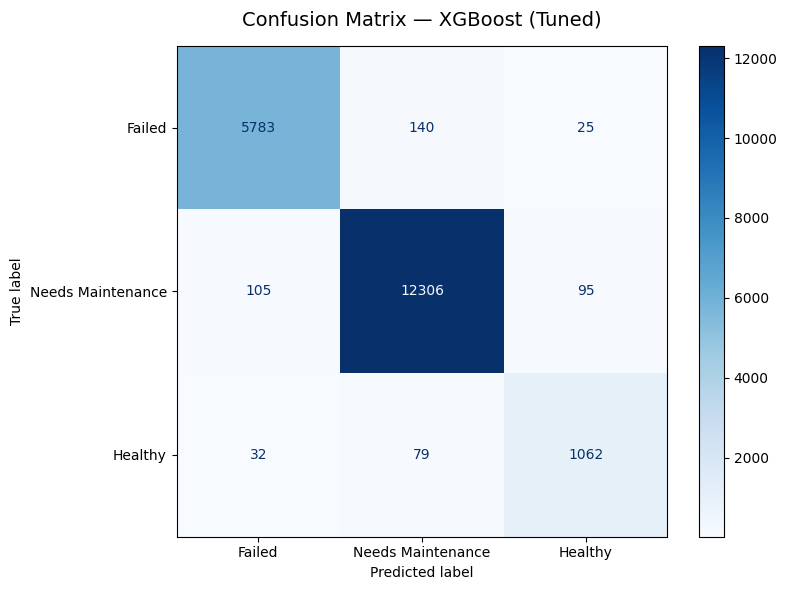

In [107]:
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Best tuned model from search
tuned_pipeline = search.best_estimator_

# Predict on test set
test_preds = tuned_pipeline.predict(X_test)

# 1. Classification Report — precision, recall, F1 per class
print("=" * 55)
print("CLASSIFICATION REPORT ON TEST SET")
print("=" * 55)
print(classification_report(
    y_test,
    test_preds,
    target_names=["Failed (0)", "Needs Maintenance (1)", "Healthy (2)"]
))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Failed", "Needs Maintenance", "Healthy"]
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
plt.title("Confusion Matrix — XGBoost (Tuned)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

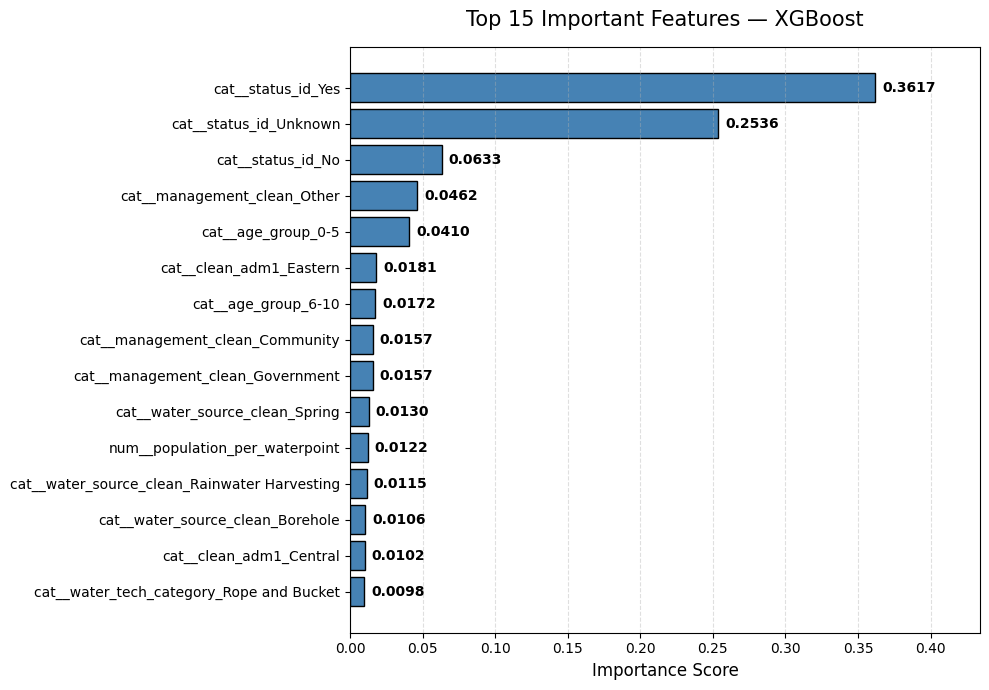

Top 10 Features:
                         Feature  Importance
              cat__status_id_Yes    0.361682
          cat__status_id_Unknown    0.253561
               cat__status_id_No    0.063337
     cat__management_clean_Other    0.046247
              cat__age_group_0-5    0.040954
         cat__clean_adm1_Eastern    0.018057
             cat__age_group_6-10    0.017206
 cat__management_clean_Community    0.015705
cat__management_clean_Government    0.015692
  cat__water_source_clean_Spring    0.012975


In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract model and feature names from pipeline
model = tuned_pipeline.named_steps["model"]
feature_names = tuned_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances
importance = model.feature_importances_

# Build dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

# Top 15 features
top15 = importance_df.head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15["Feature"], top15["Importance"],
               color="steelblue", edgecolor="black")
ax.bar_label(bars, fmt="%.4f", padding=5, fontweight="bold")
ax.set_xlim(0, top15["Importance"].max() * 1.2)
ax.invert_yaxis()
ax.set_title("Top 15 Important Features — XGBoost", fontsize=15, pad=15)
ax.set_xlabel("Importance Score", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Print top 10
print("Top 10 Features:")
print(importance_df.head(10).to_string(index=False))

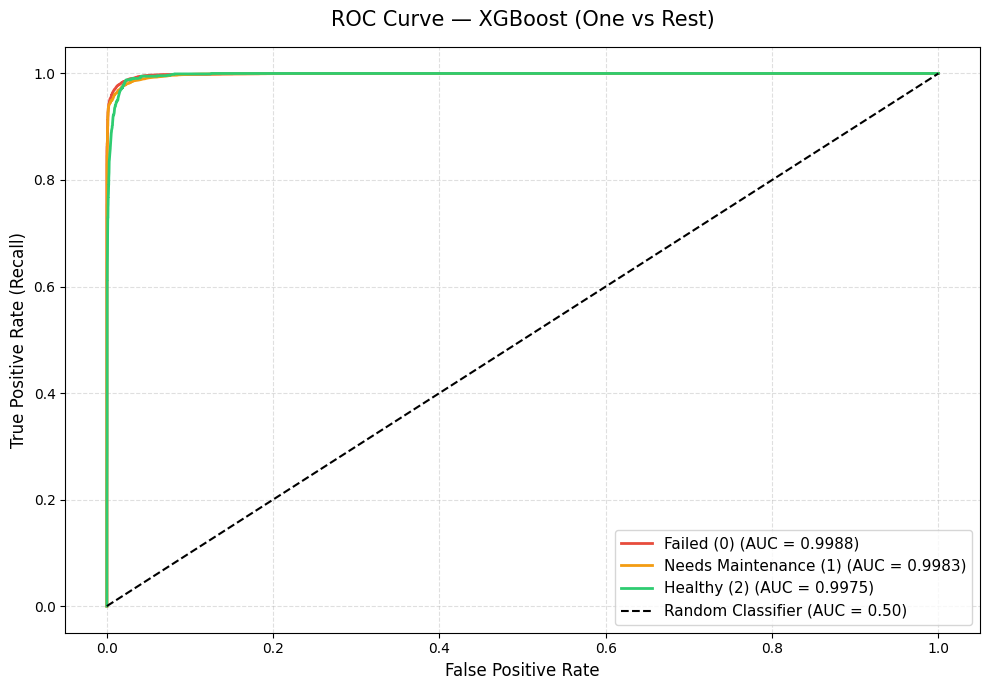


AUC per Class:
  Failed (0): 0.9988
  Needs Maintenance (1): 0.9983
  Healthy (2): 0.9975

Macro Average AUC: 0.9982


In [109]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Binarize the test labels for multiclass ROC
# This converts y_test into 3 binary columns — one per class
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# 2. Get predicted probabilities for all 3 classes
y_probs = tuned_pipeline.predict_proba(X_test)

# 3. Compute ROC curve and AUC for each class
class_names = ["Failed (0)", "Needs Maintenance (1)", "Healthy (2)"]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, ax = plt.subplots(figsize=(10, 7))

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{class_name} (AUC = {roc_auc:.4f})")

# 4. Macro average AUC across all classes
macro_auc = roc_auc_score(y_test_bin, y_probs,
                           multi_class="ovr", average="macro")

# Diagonal baseline (random classifier)
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier (AUC = 0.50)")

# Formatting
ax.set_title("ROC Curve — XGBoost (One vs Rest)", fontsize=15, pad=15)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.legend(loc="lower right", fontsize=11)
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nAUC per Class:")
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    print(f"  {class_name}: {auc(fpr, tpr):.4f}")

print(f"\nMacro Average AUC: {macro_auc:.4f}")

In [110]:
import joblib
import pandas as pd

# 1. Save the tuned pipeline
joblib.dump(tuned_pipeline, "waterpoint_failure_model.pkl")
print("✅ Model saved as waterpoint_failure_model.pkl")

# 2. Inference function
def predict_waterpoint(input_dict):
    """
    Predicts waterpoint status from raw input data.

    Parameters:
        input_dict (dict): dictionary with 7 feature values

    Returns:
        dict: predicted class, label, probabilities,
              risk score and risk level
    """
    status_map = {0: "Failed", 1: "Needs Maintenance", 2: "Healthy"}

    # Convert to dataframe
    input_df = pd.DataFrame([input_dict])
    input_df["age_group"] = input_df["age_group"].astype(str)

    # Predict
    prediction = tuned_pipeline.predict(input_df)[0]
    probabilities = tuned_pipeline.predict_proba(input_df)[0]

    # Risk score
    risk_score = (1.0 * probabilities[0]) + (0.6 * probabilities[1])

    # Risk level
    if risk_score >= 0.7:
        risk_level = "High Risk"
    elif risk_score >= 0.4:
        risk_level = "Medium Risk"
    else:
        risk_level = "Low Risk"

✅ Model saved as waterpoint_failure_model.pkl


In [111]:
# 1. Predict probabilities for entire dataset
all_probs = tuned_pipeline.predict_proba(X)

# 2. Create probabilities dataframe
prob_df = pd.DataFrame(
    all_probs,
    columns=["probability_failed", "probability_maintenance", "probability_healthy"]
).round(4)

In [112]:
prob_df.head()

,probability_failed,probability_maintenance,probability_healthy
0,0.0015,0.9985,0.0
1,0.0015,0.9985,0.0
2,0.0007,0.9993,0.0
3,1.0000,0.0000,0.0
4,1.0000,0.0000,0.0


In [113]:
# 3. Merge with original df
final_df = pd.concat([df.reset_index(drop=True), prob_df], axis=1)

In [114]:
final_df.head(50)

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,...,facility_type,count,report_year,status_numeric,Age_Group,age_group,population_per_waterpoint,probability_failed,probability_maintenance,probability_healthy
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,...,Improved,1,4,1,26-30,26-30,525.036461,0.0015,0.9985,0.0000
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,...,Improved,1,4,1,26-30,26-30,525.036461,0.0015,0.9985,0.0000
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,...,Improved,1,4,1,26-30,26-30,525.036461,0.0007,0.9993,0.0000
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,...,Improved,1,4,0,26-30,26-30,525.036461,1.0000,0.0000,0.0000
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,...,Improved,1,4,0,21-25,21-25,525.036461,1.0000,0.0000,0.0000
5,36,3.020931,30.938664,Yes,Borehole,Hand Pump,Northern,Arua,2003,23,...,Improved,1,4,1,21-25,21-25,525.036461,0.0005,0.9995,0.0000
6,41,3.022500,30.941269,Yes,Well,Unknown,Northern,Arua,2004,22,...,Improved,1,4,1,21-25,21-25,525.036461,0.0001,0.9999,0.0000
7,42,3.022275,30.941953,Yes,Well,Unknown,Northern,Arua,2004,22,...,Improved,1,4,1,21-25,21-25,525.036461,0.0001,0.9999,0.0000
8,47,3.021698,30.933338,No,Well,Unknown,Northern,Arua,1957,69,...,Improved,1,4,0,66-70,46+,525.036461,0.9999,0.0001,0.0000
9,83,3.030956,30.937952,No,Well,Unknown,Northern,Arua,1987,39,...,Improved,1,4,0,36-40,36-40,525.036461,1.0000,0.0000,0.0000


In [115]:
final_df["risk_score"] = (
    1.0 * final_df["probability_failed"] +
    0.6 * final_df["probability_maintenance"]
).round(4)

In [116]:
final_df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,...,count,report_year,status_numeric,Age_Group,age_group,population_per_waterpoint,probability_failed,probability_maintenance,probability_healthy,risk_score
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,...,1,4,1,26-30,26-30,525.036461,0.0015,0.9985,0.0,0.6006
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,...,1,4,1,26-30,26-30,525.036461,0.0015,0.9985,0.0,0.6006
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,...,1,4,1,26-30,26-30,525.036461,0.0007,0.9993,0.0,0.6003
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,...,1,4,0,26-30,26-30,525.036461,1.0000,0.0000,0.0,1.0000
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,...,1,4,0,21-25,21-25,525.036461,1.0000,0.0000,0.0,1.0000


In [117]:
final_df["risk_level"] = final_df["risk_score"].apply(
    lambda s: "High Risk" if s >= 0.7 else ("Medium Risk" if s >= 0.4 else "Low Risk")
)

In [118]:
final_df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,...,report_year,status_numeric,Age_Group,age_group,population_per_waterpoint,probability_failed,probability_maintenance,probability_healthy,risk_score,risk_level
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,...,4,1,26-30,26-30,525.036461,0.0015,0.9985,0.0,0.6006,Medium Risk
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,...,4,1,26-30,26-30,525.036461,0.0015,0.9985,0.0,0.6006,Medium Risk
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,...,4,1,26-30,26-30,525.036461,0.0007,0.9993,0.0,0.6003,Medium Risk
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,...,4,0,26-30,26-30,525.036461,1.0000,0.0000,0.0,1.0000,High Risk
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,...,4,0,21-25,21-25,525.036461,1.0000,0.0000,0.0,1.0000,High Risk


In [119]:
final_df.shape

(130842, 26)

In [120]:
print(final_df["risk_level"].value_counts())

risk_level
Medium Risk    82045
High Risk      40286
Low Risk        8511
Name: count, dtype: int64


In [121]:
final_df["priority_score"] = (
    final_df["risk_score"] *
    np.log1p(final_df["population_per_waterpoint"])
).round(4)

In [122]:
final_df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,...,status_numeric,Age_Group,age_group,population_per_waterpoint,probability_failed,probability_maintenance,probability_healthy,risk_score,risk_level,priority_score
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,...,1,26-30,26-30,525.036461,0.0015,0.9985,0.0,0.6006,Medium Risk,3.7630
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,...,1,26-30,26-30,525.036461,0.0015,0.9985,0.0,0.6006,Medium Risk,3.7630
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,...,1,26-30,26-30,525.036461,0.0007,0.9993,0.0,0.6003,Medium Risk,3.7611
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,...,0,26-30,26-30,525.036461,1.0000,0.0000,0.0,1.0000,High Risk,6.2654
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,...,0,21-25,21-25,525.036461,1.0000,0.0000,0.0,1.0000,High Risk,6.2654


In [123]:
final_df.sort_values("priority_score", ascending=False).head(50)

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,...,status_numeric,Age_Group,age_group,population_per_waterpoint,probability_failed,probability_maintenance,probability_healthy,risk_score,risk_level,priority_score
114152,538159,0.396210,32.583726,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2017,9,...,0,6-10,6-10,112357.625000,0.9999,0.0001,0.0000,1.0000,High Risk,11.6295
113861,537817,0.315710,32.525178,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2017,9,...,0,6-10,6-10,112357.625000,0.9999,0.0001,0.0000,1.0000,High Risk,11.6295
114114,538113,0.354185,32.561640,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2017,9,...,0,6-10,6-10,112357.625000,0.9999,0.0001,0.0000,1.0000,High Risk,11.6295
113922,537886,0.310854,32.543721,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2016,10,...,0,6-10,6-10,112357.625000,0.9999,0.0001,0.0000,1.0000,High Risk,11.6295
113108,535693,0.327995,32.548558,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2022,4,...,0,0-5,0-5,112357.625000,0.9997,0.0003,0.0000,0.9999,High Risk,11.6283
14574,48141,0.270000,32.600000,Unknown,unknown,Motorized Pump,Central,Kampala,2009,17,...,0,16-20,16-20,112357.625000,0.9998,0.0001,0.0001,0.9999,High Risk,11.6283
114088,538082,0.336727,32.549584,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2013,13,...,0,11-15,11-15,112357.625000,0.9803,0.0197,0.0000,0.9921,High Risk,11.5376
114077,538069,0.381444,32.587040,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2013,13,...,0,11-15,11-15,112357.625000,0.9803,0.0197,0.0000,0.9921,High Risk,11.5376
114096,538091,0.320808,32.556422,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2012,14,...,0,11-15,11-15,112357.625000,0.9803,0.0197,0.0000,0.9921,High Risk,11.5376
114072,538063,0.335318,32.639766,Yes,Rainwater Harvesting,Unknown,Central,Kampala,2013,13,...,0,11-15,11-15,112357.625000,0.9803,0.0197,0.0000,0.9921,High Risk,11.5376


/tmp/ipykernel_11756/2246205445.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_risk, patch_artist=True, labels=risk_order)


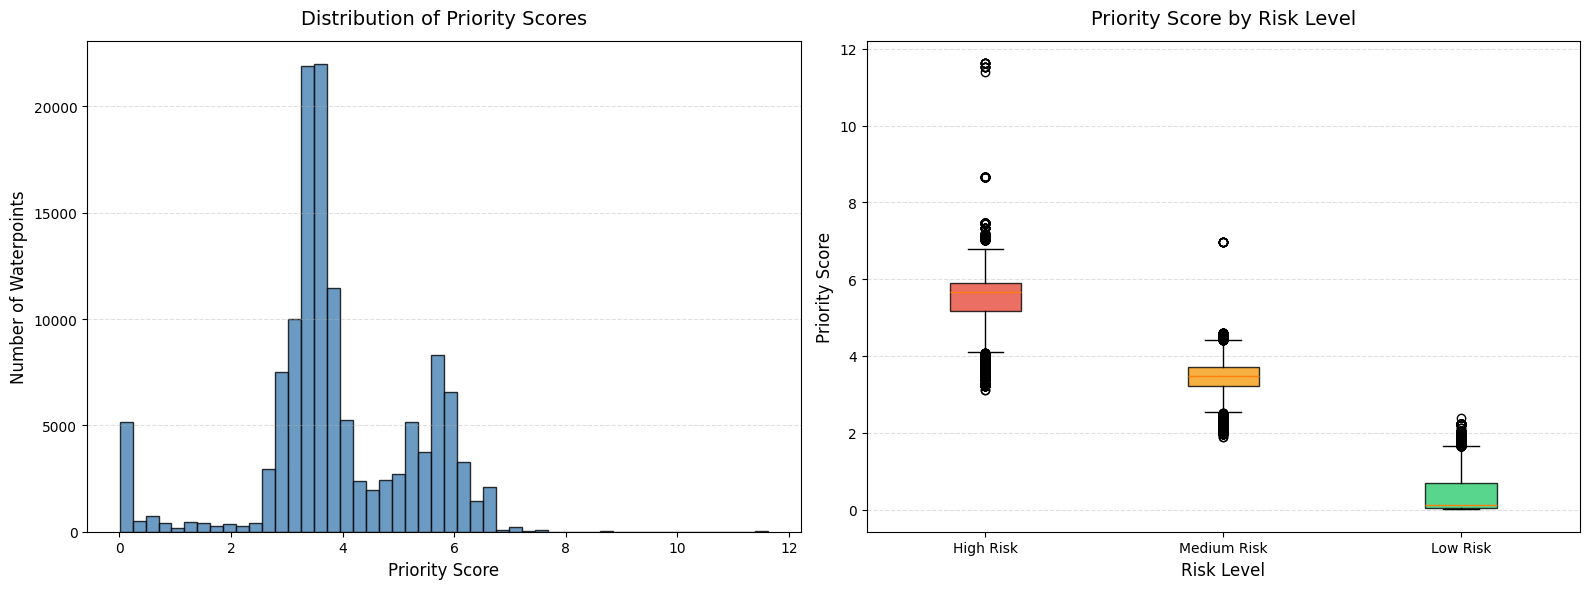


Priority Score Summary:
count    130842.0000
mean          3.8985
std           1.3978
min           0.0040
25%           3.3324
50%           3.6606
75%           5.0042
max          11.6295
Name: priority_score, dtype: float64

Priority Score by Risk Level:
               count    mean     std     min     25%     50%     75%      max
risk_level                                                                   
High Risk    40286.0  5.5317  0.6603  3.1066  5.1714  5.6562  5.8885  11.6295
Low Risk      8511.0  0.4579  0.6003  0.0040  0.0429  0.1148  0.6879   2.3853
Medium Risk  82045.0  3.4534  0.3586  1.8949  3.2276  3.4723  3.7035   6.9777


In [124]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram — overall distribution of priority scores
axes[0].hist(final_df["priority_score"], bins=50,
             color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Distribution of Priority Scores", fontsize=14, pad=12)
axes[0].set_xlabel("Priority Score", fontsize=12)
axes[0].set_ylabel("Number of Waterpoints", fontsize=12)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# 2. Priority score by risk level — boxplot
risk_order = ["High Risk", "Medium Risk", "Low Risk"]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

data_by_risk = [
    final_df[final_df["risk_level"] == level]["priority_score"]
    for level in risk_order
]

bp = axes[1].boxplot(data_by_risk, patch_artist=True, labels=risk_order)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1].set_title("Priority Score by Risk Level", fontsize=14, pad=12)
axes[1].set_xlabel("Risk Level", fontsize=12)
axes[1].set_ylabel("Priority Score", fontsize=12)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Summary stats
print("\nPriority Score Summary:")
print(final_df["priority_score"].describe().round(4))
print()
print("Priority Score by Risk Level:")
print(final_df.groupby("risk_level")["priority_score"]
      .describe().round(4).to_string())

In [125]:
import joblib

# 1. Save final dataset to Excel
final_df.to_excel("Final_Waterpoint_Predictions.xlsx", index=False)

# 2. Save trained model
joblib.dump(tuned_pipeline, "waterpoint_failure_model.pkl")

# 3. Download both files to your local machine
from google.colab import files
files.download("Final_Waterpoint_Predictions.xlsx")
files.download("waterpoint_failure_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>